# Intro to Classical ML

**Scaler CML | Applied ML (Intro)**

## How to use this notebook

1. Read each markdown block as the live-class talking track.
2. Run code cells for light demos (toy data only).
3. Pause on **Discuss** / **Think** prompts and every **Quiz** before scrolling on.
4. Quizzes list choices only (no answer keys in this notebook).


# 1. Agenda

Today we set the Classical ML map:

1. **Prior DSML refresh** (libraries, plots, probability, linear algebra)
2. **ML vs classical programming**
3. **Tom Mitchell ETP** (Experience, Task, Performance)
4. **Classification vs Regression**
5. **Supervised vs Unsupervised**

Skip announcements; stay on concepts + demos + quizzes.


# 2. Already Learnt: DSML Refresh

You already use:

| Area | Tools | Role |
|---|---|---|
| Numerics | NumPy | Arrays, linear algebra ops |
| Tables | Pandas | Wrangle tabular data |
| Plots | Matplotlib / Seaborn | See distributions and relationships |
| Probability | Expectation, variance, distributions | Talk about uncertainty |
| Linear algebra | Vectors, matrices, dot products | Geometry of features and models |

**Plot choice table:**

| Need | Prefer |
|---|---|
| Shape of a distribution | Histogram |
| Category comparison | Bar |
| Two continuous variables | Scatter |
| Ordered trend | Line |

**Discuss:** Exam scores for 200 students. Do you reach for a histogram or a scatter first? Why?


# Quiz 1

**You want to display the distribution of students' scores in a class. Which plot is best suited for this task?**

- Bar Plot
- Histogram
- Scatter Plot
- Line Plot


# 3. ML vs Classical Programming

**Classical / SDE style:** engineer writes rules. Input + code → output.

**Machine Learning:** data drives the rules. Examples teach a mapping that scores well on a performance measure.

| | Classical | ML |
|---|---|---|
| Rules from | Hand-written logic | Learned from data |
| Best when | Spec is clear and stable | Pattern is hard to hand-code |
| Change management | Edit code | Retrain / update with new data |

**SDE pipeline sketch:** requirements → explicit algorithm → tests → deploy.

**ML pipeline sketch:** frame problem → data → train model → evaluate holdout → deploy + monitor.

**Think:** Spam filtering. Would you rather maintain thousands of keyword rules, or learn from labeled mailboxes?


# 4. Tom Mitchell: Well-Defined Learning (ETP)

Paraphrase used in class:

> A program **learns** from experience $E$ on task $T$ with performance $P$ if performance at $T$, measured by $P$, improves with $E$.

| Symbol | Meaning | Prompt |
|---|---|---|
| $T$ | Task | What must the system do? |
| $E$ | Experience | What data or interaction teaches it? |
| $P$ | Performance | How do we score success? |

**Example (spam):**

- $T$: label email spam / not spam
- $E$: historical labeled emails
- $P$: precision/recall or F1 on held-out mail

**Example (house price):**

- $T$: predict price from features
- $E$: past sales with known prices
- $P$: MAE or RMSE on unseen houses

**Discuss:** Write $T$, $E$, $P$ for "recommend the next movie" in one line each.


# Quiz 2

**Which of the following provides the best explanation of Machine Learning?**

- Machine learning learns from labelled data
- Machine learning is the field of giving robots the ability to act intelligently.
- ML enables computers to learn without explicit programming
- Machine learning is the science of programming computers.


# 5. Classification vs Regression

**Classification:** predict a **discrete** class label (spam/ham, digit 0-9, churn yes/no).

**Regression:** predict a **continuous** number (price, temperature, demand).

| | Classification | Regression |
|---|---|---|
| Target | Discrete | Continuous |
| Typical metrics | Accuracy, F1, AUC | MAE, MSE, RMSE, $R^{2}$ |
| Example | Will they churn? | How much will they spend? |

Inputs may be discrete, continuous, or mixed in **both** cases. The fork is the **output type**.

**Invented demo (below):** same 2D feature plane; one panel colors discrete classes, the other shows a continuous target with a fitted line. Toy data only, not a real project.


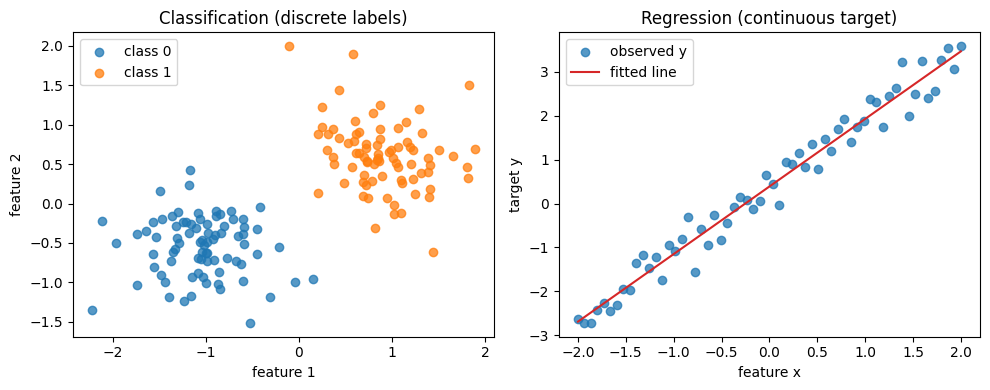

Classification unique labels: [0 1]
Regression y range: [-2.72, 3.59]


In [1]:
# Invented demo: toy classification vs regression on synthetic 2D / 1D data
# (Session 1 teaching sketch  -  not a production model)

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

# --- Classification sketch: two blobs, discrete labels ---
n = 80
X0 = rng.normal(loc=[-1.0, -0.5], scale=0.45, size=(n, 2))
X1 = rng.normal(loc=[1.0, 0.6], scale=0.45, size=(n, 2))
X_clf = np.vstack([X0, X1])
y_clf = np.array([0] * n + [1] * n)

# --- Regression sketch: y continuous in x ---
x_reg = np.linspace(-2, 2, 60)
y_reg = 1.5 * x_reg + 0.4 + rng.normal(0, 0.35, size=x_reg.shape)
# simple closed-form line fit for the sketch
w1 = np.cov(x_reg, y_reg, bias=True)[0, 1] / np.var(x_reg)
w0 = y_reg.mean() - w1 * x_reg.mean()
y_hat = w0 + w1 * x_reg

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(X_clf[y_clf == 0, 0], X_clf[y_clf == 0, 1], alpha=0.75, label="class 0")
axes[0].scatter(X_clf[y_clf == 1, 0], X_clf[y_clf == 1, 1], alpha=0.75, label="class 1")
axes[0].set_title("Classification (discrete labels)")
axes[0].set_xlabel("feature 1")
axes[0].set_ylabel("feature 2")
axes[0].legend()

axes[1].scatter(x_reg, y_reg, alpha=0.75, label="observed y")
axes[1].plot(x_reg, y_hat, color="C3", label="fitted line")
axes[1].set_title("Regression (continuous target)")
axes[1].set_xlabel("feature x")
axes[1].set_ylabel("target y")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Classification unique labels:", np.unique(y_clf))
print(f"Regression y range: [{y_reg.min():.2f}, {y_reg.max():.2f}]")


**Observe:** Left panel: color = class identity (discrete). Right panel: height = numeric target (continuous). Same "learning from examples" idea; different output type.


# Quiz 3

**What is the main purpose of regression analysis in machine learning?**

- To classify data into distinct categories.
- To predict a continuous outcome or value.
- To perform clustering on the dataset.
- To visualize high-dimensional data.


# Quiz 4

**Which of the followings is/are true about classification?**

- Classification can be defined as a predictive model mapping inputs to discrete outputs
- Class label prob. enables classification algos to predict continuous values.
- A classification algorithm can have both discrete and real-valued input variables.
- All of the options


# 6. Supervised vs Unsupervised

**Supervised:** each training row has a target $y$. Learn $x \mapsto y$. Classification and regression live here.

**Unsupervised:** only $x$. Discover structure (clusters, compressions) without provided labels.

| | Supervised | Unsupervised |
|---|---|---|
| Labels? | Yes | No |
| Goal | Predict $y$ | Find structure in $x$ |
| Examples | Classifier, regressor | Clustering, PCA |

**Bridge stories:**

- Property dealer with historical **prices** → regression (supervised).
- Feedback comments with **no topic tags** yet → unsupervised topic/cluster discovery.
- Stock series with a known future price to predict → supervised.
- HR wants applicants in **already named** groups → supervised classification into those groups.

**Invented demo (below):** `KMeans` on a toy 2D mixture. Labels used only for coloring the truth; the algorithm does **not** receive them. Teaching sketch only.


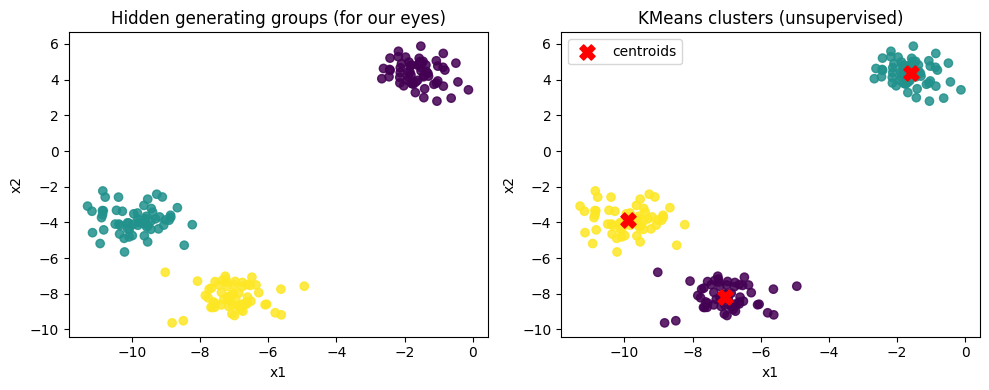

KMeans never saw y_true during fit; it only saw X.
Cluster sizes: [60 60 60]


In [2]:
# Invented demo: simple unsupervised clustering sketch with sklearn
# (Session 1 teaching sketch  -  toy blobs, not a business dataset)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y_true = make_blobs(n_samples=180, centers=3, cluster_std=0.70, random_state=1)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=1)
y_hat = kmeans.fit_predict(X)  # fit uses X only  -  no y_true

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap="viridis", alpha=0.85)
axes[0].set_title("Hidden generating groups (for our eyes)")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

axes[1].scatter(X[:, 0], X[:, 1], c=y_hat, cmap="viridis", alpha=0.85)
axes[1].scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    marker="X",
    s=120,
    label="centroids",
)
axes[1].set_title("KMeans clusters (unsupervised)")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].legend()

plt.tight_layout()
plt.show()

print("KMeans never saw y_true during fit; it only saw X.")
print("Cluster sizes:", np.bincount(y_hat))


**Observe:** Unsupervised learning invents groups from geometry in feature space. That is different from classification, which predicts **pre-defined** class names.

**Think:** If HR already has named buckets ("reject / interview / offer"), is clustering enough, or do you need labeled supervised classification?


# Quiz 5

**A property dealer has a dataset consisting of features like area, price, etc. Now a customer comes to him asking for a property with a certain number of rooms.**

**Which kind of machine learning technique should the property dealer use from the following?**

- Classification
- Clustering
- Regression


# Quiz 6

**You have a dataset of customer feedback comments, and you want to categorize them into different topics, such as product quality, customer service, and delivery. Is this a supervised or unsupervised learning problem?**

- Supervised learning
- Unsupervised learning


# Quiz 7

**You are working on a project to predict stock prices based on historical market data, and you have a dataset with features such as past stock prices, trading volume, and other market indicators. Is this a supervised or unsupervised learning problem?**

- Supervised learning
- Unsupervised learning


# Quiz 8

**Your supervisor asks you to create a machine learning system that will help your human resources department classify jobs applicants into well-defined groups. What type of system are you more likely to recommend?**

- an unsupervised machine learning system that clusters together the best candidates.
- you would not recommend a machine learning system for this type of project.
- a supervised machine learning system that classifies applicants into existing groups.


# Wrap-up

You should now be able to:

1. Pick a plot that matches the question (especially histograms for distributions).
2. Contrast classical rule-writing with learning from data.
3. State a problem as Experience $E$, Task $T$, Performance $P$.
4. Separate classification (discrete $y$) from regression (continuous $y$).
5. Tell supervised prediction apart from unsupervised structure discovery (e.g. clustering).
